# MLR Plots




## Wandb Server Request

In [1]:
import os
import wandb
import numpy as np
import matplotlib.pyplot as plt

In [2]:
os.environ['WANDB_API_KEY'] = "TODO"

In [3]:
proj = "struct_sequence_mixing"

In [4]:
api = wandb.Api()
tag_filter = {
    "tags": {"$in": [        
        "MLR_Long_Context_Corrected",        
    ]}, 
}

runs = api.runs(proj, filters=tag_filter, order='-created_at')

In [5]:
all_data = {}
param_data = {}

for run in runs:
    history = run.history(keys=["non_emb_compute", "train/loss", "val/loss"])
    history["run_id"] = run.id

    if "token_mixing_struct" in run.config:
        if run.config["token_mixing_struct"] == "bilinear_MLR":
            curr_token_mixing_struct = "BilinearMLR"
        elif run.config["token_mixing_struct"] == "low_rank_with_sliding_window":
            curr_token_mixing_struct = "LR_SWA"
        elif run.config["token_mixing_struct"] == "low_rank_with_gswa":
            curr_token_mixing_struct = "LR_GSWA"
        else:
            curr_token_mixing_struct = "MLR"
    else:
        curr_token_mixing_struct = "MLR"
    
    if "mlr_rank_list" in run.config:
        # Standard Attention
        if run.config['mlr_rank_list'] == "64|0":
            num_levels = 1
            str_name = f"{curr_token_mixing_struct}_{num_levels}_levels_{run.config['mlr_rank_list']}_divide_{run.config['mlr_divide_by_num_levels']}_lr{run.config['init_lr']}_dm_{run.config['d_model']}"
        # MLR Attention
        else:
            num_levels = len(run.config['mlr_rank_list'].split("|"))
        
            if "mlr_divide_by_num_levels" in run.config:
                str_name = f"{curr_token_mixing_struct}_{num_levels}_levels_{run.config['mlr_rank_list']}_divide_{run.config['mlr_divide_by_num_levels']}_lr{run.config['init_lr']}_dm_{run.config['d_model']}"
            else:
                str_name = f"{curr_token_mixing_struct}_{num_levels}_levels_{run.config['mlr_rank_list']}_lr{run.config['init_lr']}_dm_{run.config['d_model']}"

        # d_qk_head 
        if "d_qk_head" in run.config:
            str_name = f"{str_name}_dqkh_{run.config["d_qk_head"]}"
        else:
            if run.config["token_mixing_struct"] == "dense_mlr":
                _list_of_ranks = list(map(int, run.config['mlr_rank_list'].split("|")))
                _list_of_blocks = [2**idx for idx in range(len(_list_of_ranks))]
                d_qk_head = sum(a * b for a, b in zip(_list_of_ranks, _list_of_blocks))
                str_name = f"{str_name}_dqkh_{d_qk_head}"
            else:
                str_name = f"{str_name}_dqkh_64"
                
        # mlr_block_divide_by_num_levels
        if "mlr_block_divide_by_num_levels" in run.config:
            if run.config["mlr_block_divide_by_num_levels"] == True:
                str_name = f"{str_name}_mlr_block_divide_True"
            else:
                str_name = f"{str_name}_mlr_block_divide_False"
        else:
            str_name = f"{str_name}_mlr_block_divide_False"
    else:
        str_name = f'{run.name}_lr{run.config['init_lr']}_dm_{run.config['d_model']}'

    if "bad_lr" in run.tags:
        str_name += "_bad_lr_True"
    else:
        str_name += "_bad_lr_False"

    all_data[str_name] = history

    if "non_emb_params" in run.config:
        param_data[str_name] = run.config["non_emb_params"]


In [6]:
# for key in all_data:
#     print(key)
    
all_data_optimal_lr = {}
for key in all_data:
    if "bad_lr_False" in key:
        all_data_optimal_lr[key] = all_data[key]
        print(key)

LR_GSWA_1_levels_64|0_divide_False_lr0.003_dm_512_dqkh_64_mlr_block_divide_False_bad_lr_False
LR_GSWA_1_levels_64|0_divide_False_lr0.003_dm_384_dqkh_64_mlr_block_divide_False_bad_lr_False
LR_GSWA_1_levels_64|0_divide_False_lr0.003_dm_256_dqkh_64_mlr_block_divide_False_bad_lr_False
LR_GSWA_1_levels_64|0_divide_False_lr0.0165_dm_768_dqkh_64_mlr_block_divide_False_bad_lr_False
LR_SWA_1_levels_64|0_divide_False_lr0.003_dm_768_dqkh_64_mlr_block_divide_False_bad_lr_False
LR_SWA_1_levels_64|0_divide_False_lr0.003_dm_256_dqkh_64_mlr_block_divide_False_bad_lr_False
LR_SWA_1_levels_64|0_divide_False_lr0.003_dm_384_dqkh_64_mlr_block_divide_False_bad_lr_False
LR_SWA_1_levels_64|0_divide_False_lr0.003_dm_512_dqkh_64_mlr_block_divide_False_bad_lr_False
MLR_8_levels_32|8|6|4|4|4|4|2_divide_False_lr0.0165_dm_768_dqkh_64_mlr_block_divide_True_bad_lr_False
MLR_8_levels_32|8|6|4|4|4|4|2_divide_False_lr0.0165_dm_384_dqkh_64_mlr_block_divide_True_bad_lr_False
MLR_1_levels_64|0_divide_False_lr0.00165_dm_768

## Scaling Law

In [7]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib

# Use a serif font for academic styling
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'legend.fontsize': 16,
})


1.0274877548217773
1.0070995092391968
0.97202467918396
0.9732470512390137
0.9396771192550659
0.9440707564353943
0.904805064201355
0.9398176074028015


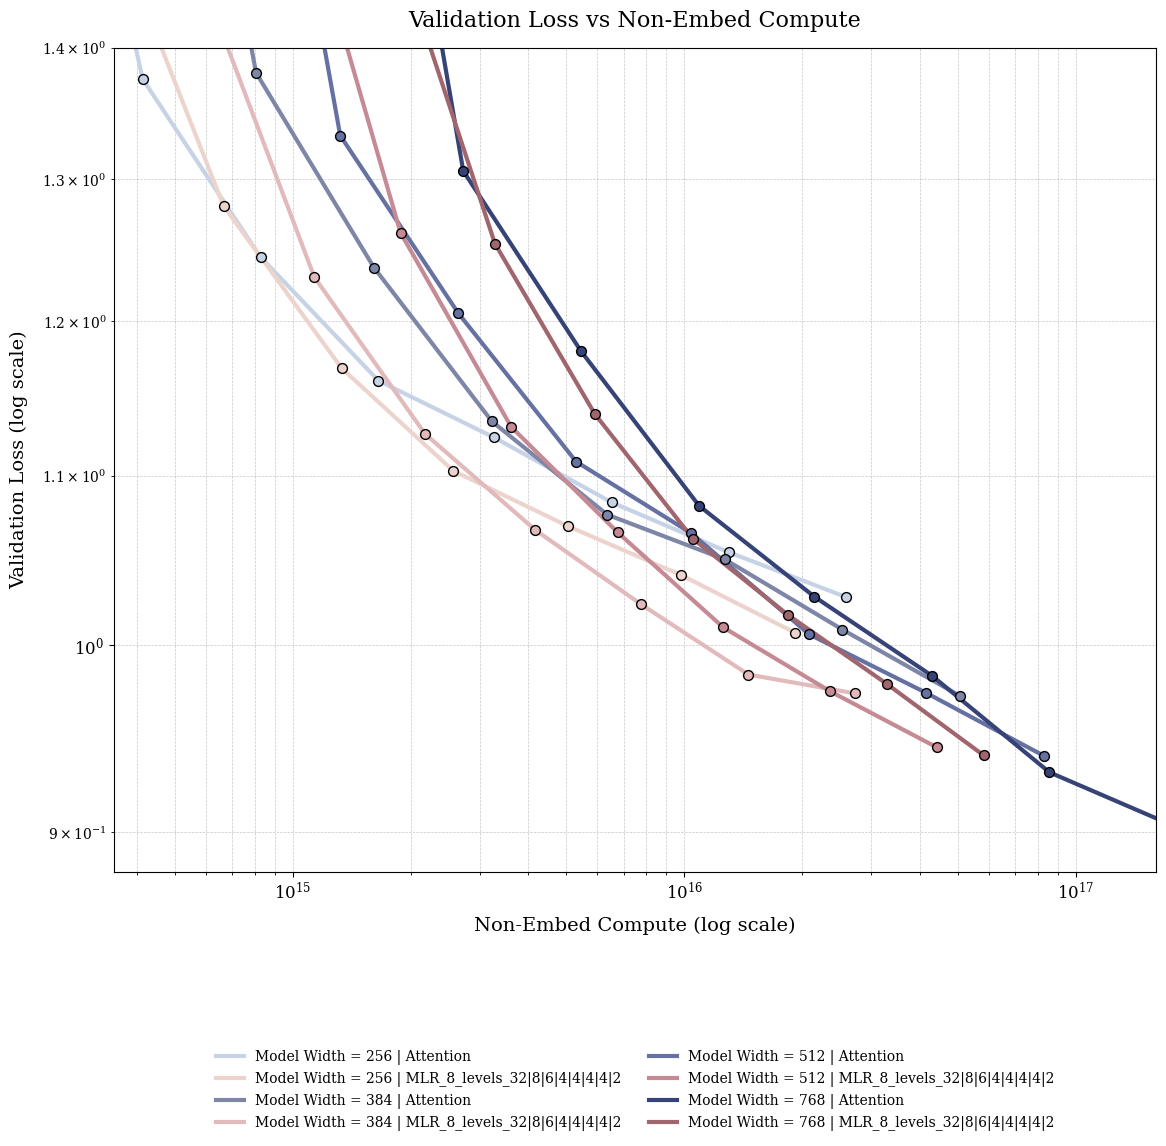

In [8]:
list_of_dm = ["dm_256", "dm_384", "dm_512", "dm_768"]
# list_of_structure = ["MLR_1_levels_64|0", "LR_SWA", "LR_GSWA", "MLR_8_levels_32|8|6|4|4|4|4|2"]
list_of_structure = ["MLR_1_levels_64|0", "MLR_8_levels_32|8|6|4|4|4|4|2"]
# list_of_structure = ["MLR_1_levels_64|0", "LR_GSWA", "MLR_8_levels_32|8|6|4|4|4|4|2"]

list_of_lr = ["lr0.03", "lr0.0165", "lr0.003", "lr0.00165"] # ["lr0.3", "lr0.165", "lr0.03", "lr0.0165", "lr0.003", "lr0.00165", "lr0.0003"]
eval_interval=200
irreducible_loss=0.75
# irreducible_loss=0
num_samples_log_scale = 10  # Adjust as needed

# Create the plot
plt.figure(figsize=(12, 12))

colors_MLR_1levels = ["#C6D3E7", "#7E86A7", "#6571A3", "#364377"]
colors_MLR_8levels = ["#ECD4CC", "#E2BABC", "#C58A93", "#A1656D"]
colors_LR_GSWA = ["#D9F1F0", "#AEDCDC", "#6EB0AF", "#4B8384"]
colors_LR_SWA = ["#FFE4D6", "#FFC5A3", "#FF9F6D", "#E2703C"]


# # Green Gradient
# green_gradient = ["#E4F0E5", "#C0D9C5", "#88A685", "#5D805A", "#2E5131"]

# # Orange Gradient
# orange_gradient = ["#FFE4D6", "#FFC5A3", "#FF9F6D", "#E2703C", "#8C441F"]

# # Yellow Gradient
# yellow_gradient = ["#FFF9D9", "#FBECA2", "#F5D974", "#D3B446", "#8B741A"]

# # Teal Gradient
# teal_gradient = ["#D9F1F0", "#AEDCDC", "#6EB0AF", "#4B8384", "#285051"]

# # Red Gradient
# red_gradient = ["#FBE4E4", "#F7B3B3", "#F47A7A", "#D14444", "#800000"]

# # Pink Gradient
# pink_gradient = ["#FDE8F2", "#F9C1DA", "#F193B7", "#D15C89", "#8A2F52"]


for i, dm in enumerate(list_of_dm):
    for structure in list_of_structure:
        for key in all_data_optimal_lr:
            if dm in key and structure in key:
                # Determine color based on the structure group
                if structure == "MLR_1_levels_64|0":
                    color = colors_MLR_1levels[i]
                    label_for_legend = "Attention"
                elif structure == "MLR_8_levels_32|8|6|4|4|4|4|2":
                    color = colors_MLR_8levels[i]
                    label_for_legend = structure
                elif structure == "LR_GSWA":
                    color = colors_LR_GSWA[i]
                    label_for_legend = structure
                elif structure == "LR_SWA":
                    color = colors_LR_SWA[i]
                    label_for_legend = structure
                else:
                    raise ValueError

                # Extract data
                x = np.array(all_data_optimal_lr[key]['non_emb_compute'])
                y = np.array(all_data_optimal_lr[key]['val/loss'])

                # Sort x and y for proper log spacing
                sorted_indices = np.argsort(x)
                x = x[sorted_indices]
                y = y[sorted_indices]

                # Perform logarithmic subsampling
                log_x = np.log10(x)  # Convert x to log scale
                log_x_subsampled = np.linspace(log_x[0], log_x[-1], num_samples_log_scale)  # Evenly spaced in log scale
                x_subsampled = 10 ** log_x_subsampled  # Convert back to original scale

                # Find the closest points in the original data for the subsampled log points
                subsample_indices = [np.abs(x - xi).argmin() for xi in x_subsampled]
                x_subsampled = x[subsample_indices]
                y_subsampled = y[subsample_indices]

                # Plot the full line
                plt.loglog(x_subsampled, y_subsampled, label=f"Model Width = {dm.split('_')[-1]} | {label_for_legend}", color=color, linewidth=3)

                # Plot scatter points on the subsampled data
                plt.scatter(x_subsampled, y_subsampled, color=color, s=50, edgecolor='black', zorder=5)

                # plt.loglog(
                #     all_data_optimal_lr[key]['non_emb_compute'], 
                #     all_data_optimal_lr[key]['val/loss']-irreducible_loss, 
                #     label=f"Model Width = {dm.split('_')[-1]} | {label_for_legend}",  # Add label for the first group only
                #     color=color,
                #     linewidth=2,
                # )
                print(all_data_optimal_lr[key]['val/loss'].iloc[-1])

# Customize the plot for an academic paper style
plt.xlabel("Non-Embed Compute (log scale)", fontsize=14, labelpad=10)
plt.ylabel("Validation Loss (log scale)", fontsize=14, labelpad=10)
plt.grid(visible=True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=10)
plt.title("Validation Loss vs Non-Embed Compute", fontsize=16, pad=15)
plt.ylim(0.88, 1.4)
plt.xlim([3.5*(10**14),1.6*(10**17)])

# Move the legend to the bottom of the plot
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),  # Adjust position
    ncol=2,  # Display legends in two columns
    fontsize=10,
    frameon=False
)
plt.tight_layout()
plt.savefig(f"overall_mlr_long_context_loss_vs_flops.png", dpi=300, bbox_inches="tight")  # Save as high-res PDF
plt.show()


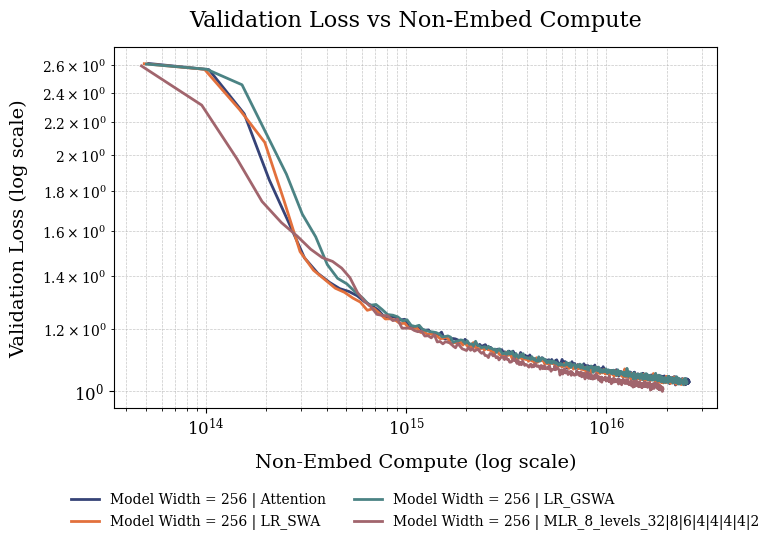

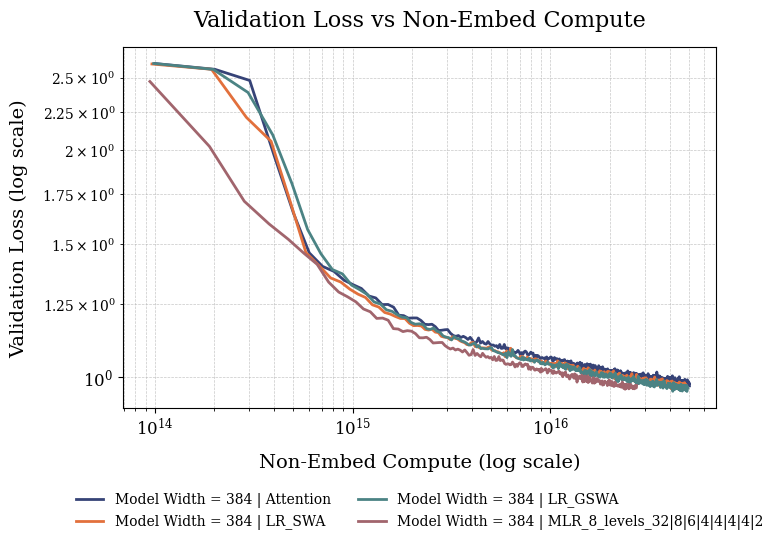

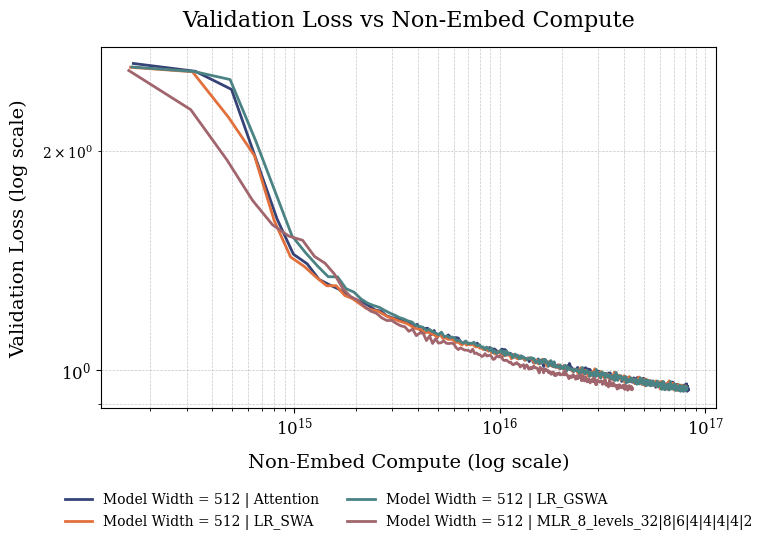

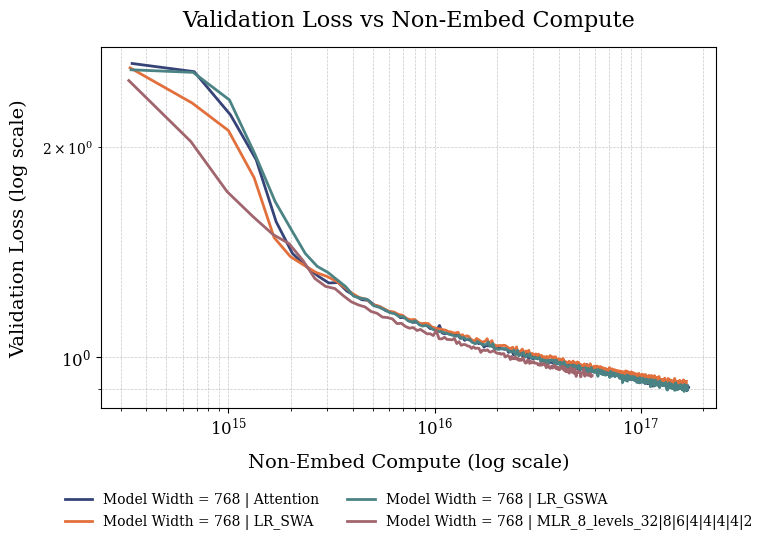

In [9]:
list_of_dm = ["dm_256", "dm_384", "dm_512", "dm_768"]
list_of_structure = ["MLR_1_levels_64|0", "LR_SWA", "LR_GSWA", "MLR_8_levels_32|8|6|4|4|4|4|2"]
list_of_lr = ["lr0.03", "lr0.0165", "lr0.003", "lr0.00165"] # ["lr0.3", "lr0.165", "lr0.03", "lr0.0165", "lr0.003", "lr0.00165", "lr0.0003"]
eval_interval=200


colors_MLR_1levels = ["#364377" for _ in range(len(list_of_dm))]
colors_MLR_8levels = ["#A1656D" for _ in range(len(list_of_dm))]
colors_LR_GSWA = ["#4B8384" for _ in range(len(list_of_dm))]
colors_LR_SWA = ["#E2703C" for _ in range(len(list_of_dm))]

for i, dm in enumerate(list_of_dm):
    # Create the plot
    plt.figure(figsize=(8, 6))

    for structure in list_of_structure:
        for key in all_data_optimal_lr:
            if dm in key and structure in key:
                # Determine color based on the structure group
                if structure == "MLR_1_levels_64|0":
                    color = colors_MLR_1levels[i]
                    label_for_legend = "Attention"
                elif structure == "MLR_8_levels_32|8|6|4|4|4|4|2":
                    color = colors_MLR_8levels[i]
                    label_for_legend = structure
                elif structure == "LR_GSWA":
                    color = colors_LR_GSWA[i]
                    label_for_legend = structure
                elif structure == "LR_SWA":
                    color = colors_LR_SWA[i]
                    label_for_legend = structure
                else:
                    raise ValueError
                    
                plt.loglog(
                    all_data_optimal_lr[key]['non_emb_compute'], 
                    all_data_optimal_lr[key]['val/loss'], 
                    label=f"Model Width = {dm.split('_')[-1]} | {label_for_legend}",  # Add label for the first group only
                    color=color,
                    linewidth=2,
                )
    
    # Customize the plot for an academic paper style
    plt.xlabel("Non-Embed Compute (log scale)", fontsize=14, labelpad=10)
    plt.ylabel("Validation Loss (log scale)", fontsize=14, labelpad=10)
    plt.grid(visible=True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.tick_params(axis='both', which='minor', labelsize=10)
    plt.title("Validation Loss vs Non-Embed Compute", fontsize=16, pad=15)
    # plt.ylim([0.9,1.5])
    
    # Move the legend to the bottom of the plot
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.2),  # Adjust position
        ncol=2,  # Display legends in two columns
        fontsize=10,
        frameon=False
    )
    plt.tight_layout()
    plt.savefig(f"mlr_long_context_loss_vs_flops_{dm}.png", dpi=300, bbox_inches="tight")  # Save as high-res PDF
    plt.show()


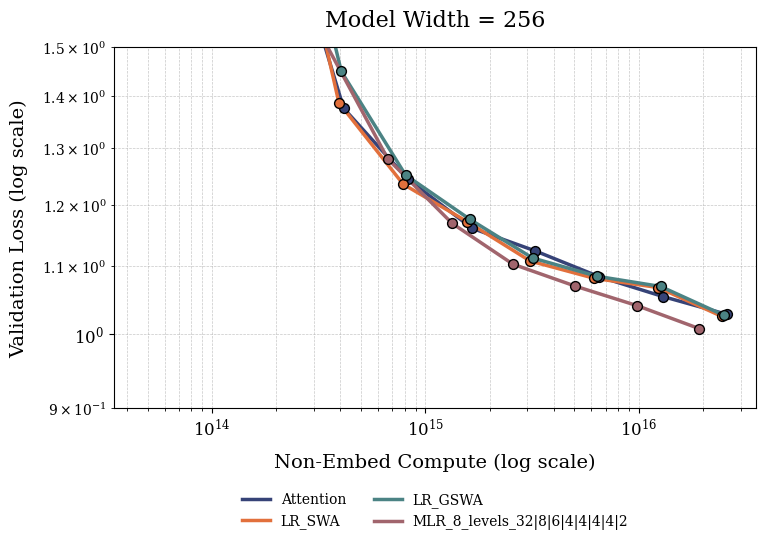

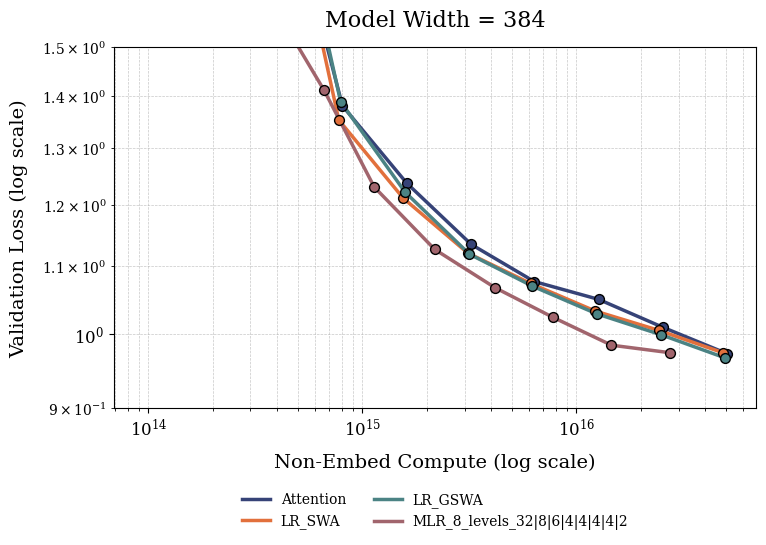

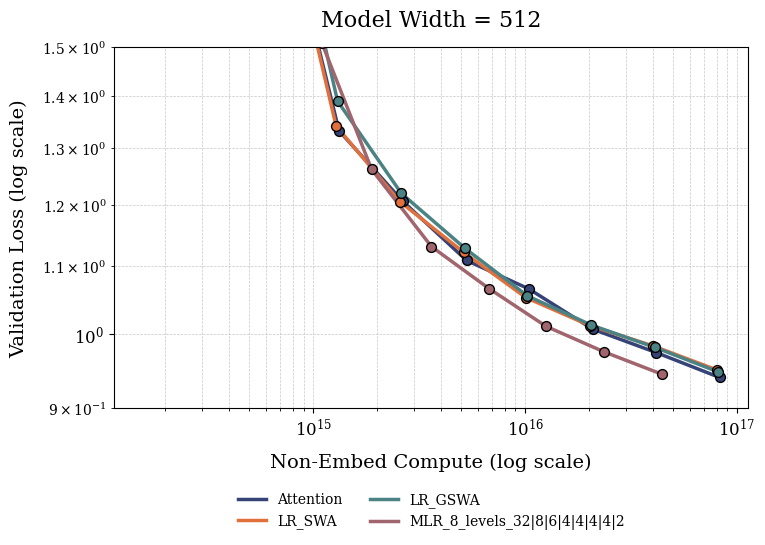

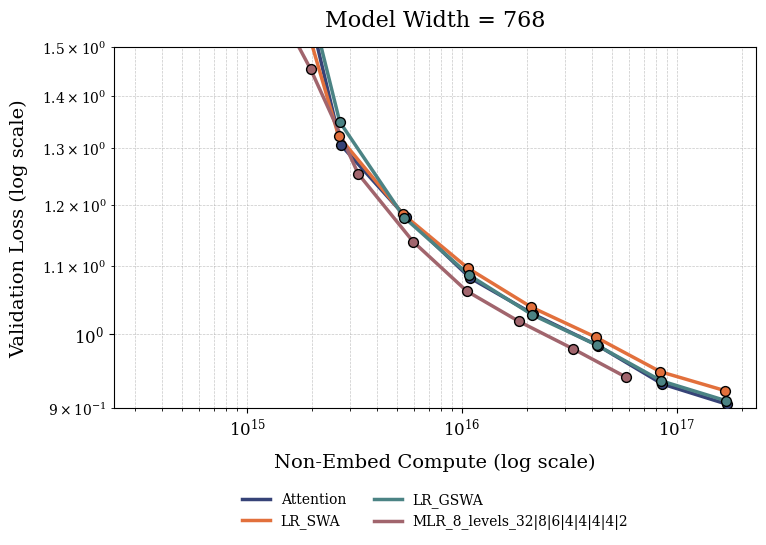

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define your subsampling interval (number of points to sample in log space)
num_samples_log_scale = 10  # Adjust as needed

for i, dm in enumerate(list_of_dm):
    # Create the plot
    plt.figure(figsize=(8, 6))

    for structure in list_of_structure:
        for key in all_data_optimal_lr:
            if dm in key and structure in key:
                # Determine color based on the structure group
                if structure == "MLR_1_levels_64|0":
                    color = colors_MLR_1levels[i]
                    label_for_legend = "Attention"
                elif structure == "MLR_8_levels_32|8|6|4|4|4|4|2":
                    color = colors_MLR_8levels[i]
                    label_for_legend = structure
                elif structure == "LR_GSWA":
                    color = colors_LR_GSWA[i]
                    label_for_legend = structure
                elif structure == "LR_SWA":
                    color = colors_LR_SWA[i]
                    label_for_legend = structure
                else:
                    raise ValueError

                # Extract data
                x = np.array(all_data_optimal_lr[key]['non_emb_compute'])
                y = np.array(all_data_optimal_lr[key]['val/loss'])

                # Sort x and y for proper log spacing
                sorted_indices = np.argsort(x)
                x = x[sorted_indices]
                y = y[sorted_indices]

                # Perform logarithmic subsampling
                log_x = np.log10(x)  # Convert x to log scale
                log_x_subsampled = np.linspace(log_x[0], log_x[-1], num_samples_log_scale)  # Evenly spaced in log scale
                x_subsampled = 10 ** log_x_subsampled  # Convert back to original scale

                # Find the closest points in the original data for the subsampled log points
                subsample_indices = [np.abs(x - xi).argmin() for xi in x_subsampled]
                x_subsampled = x[subsample_indices]
                y_subsampled = y[subsample_indices]

                # Plot the full line
                plt.loglog(x_subsampled, y_subsampled, label=f"{label_for_legend}", color=color, linewidth=2.5)

                # Plot scatter points on the subsampled data
                plt.scatter(x_subsampled, y_subsampled, color=color, s=50, edgecolor='black', zorder=5)

    # Customize the plot for an academic paper style
    plt.xlabel("Non-Embed Compute (log scale)", fontsize=14, labelpad=10)
    plt.ylabel("Validation Loss (log scale)", fontsize=14, labelpad=10)
    plt.grid(visible=True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.tick_params(axis='both', which='minor', labelsize=10)
    plt.title(f"Model Width = {dm.split('_')[-1]}", fontsize=16, pad=15)
    plt.ylim([0.9,1.5])

    # Move the legend to the bottom of the plot
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.2),  # Adjust position
        ncol=2,  # Display legends in two columns
        fontsize=10,
        frameon=False
    )
    plt.tight_layout()
    plt.savefig(f"mlr_long_context_loss_vs_flops_{dm}_subsample.png", dpi=300, bbox_inches="tight")  # Save as high-res PDF
    plt.show()
